In [1]:
!pip install rasterio geopandas shapely scikit-learn xgboost lightgbm seaborn

*Mount google drive*

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import rasterio
import shapely
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rasterio.mask import mask


In [4]:
raster_data = '/content/drive/MyDrive/kaski.tif'
raster = rasterio.open(raster_data)
img = raster.read()
print("image shape:",img.shape)


image shape: (7, 2028, 1941)


visualize band

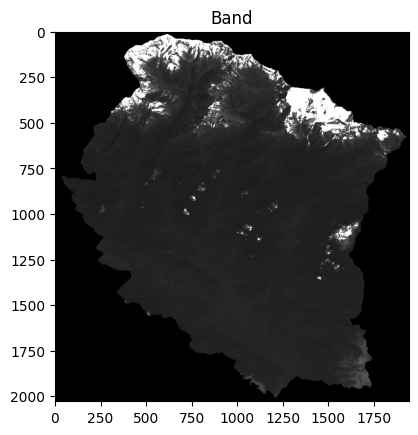

In [5]:
plt.imshow(img[0], cmap='gray')
plt.title("Band")
plt.show()

In [6]:
training_data = '/content/drive/My Drive/intersect.shp'
data = gpd.read_file(training_data)
data.head()

,Class,b1_kaski20,b2_kaski20,b3_kaski20,b4_kaski20,b5_kaski20,b6_kaski20,b7_kaski20,geometry
0,2,8570,9233,9327,12558,11719,41222,9729,POINT (205170 3117810)
1,2,8779,9459,9526,15076,14289,41751,10981,POINT (205080 3117840)
2,2,8465,9008,8630,13886,11842,41348,9479,POINT (205110 3117840)
3,2,8359,8782,8730,12824,11474,41086,9479,POINT (205140 3117840)
4,2,8359,8895,8531,12691,10985,40785,9102,POINT (205170 3117840)


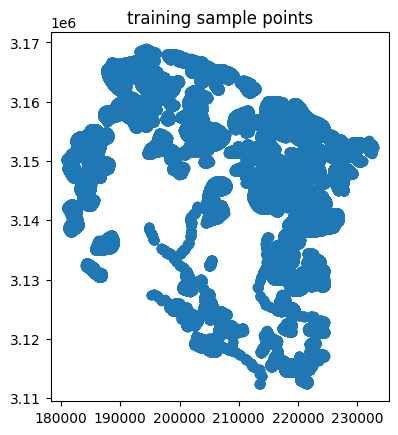

In [7]:
data.plot()
plt.title('training sample points')
plt.show()

Extract Raster Values at Point Locations (Feature Engineering)

In [8]:
# Features = all band columns
bands = ['b1_kaski20','b2_kaski20','b3_kaski20','b4_kaski20','b5_kaski20','b6_kaski20','b7_kaski20']
X = data[bands].values
y = data['Class'].values

print(X.shape, y.shape)

(439554, 7) (439554,)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import cohen_kappa_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier

import xgboost as xgb
import lightgbm as lgb

In [10]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.33, random_state=42)

In [16]:
models = {
    "RF":RandomForestClassifier(n_estimators=200),
    "SVM":SVC(),
    "DecisionTree":DecisionTreeClassifier(),
    "KNN":KNeighborsClassifier(),
    "GradientBoosting":GradientBoostingClassifier(),
    "XGBoost": xgb.XGBClassifier(),
    "LightGBM": lgb.LGBMClassifier()
}

results = {}

In [ ]:
result = {}
for name, model in models.items():
  print(f"\n..{name}..")
  model.fit(X_train,y_train)
  y_predict = model.predict(X_test)

  #metrics
  accuracy = accuracy_score(y_test,y_predict)
  kappa = cohen_kappa_score(y_test,y_predict)
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Cohen's Kappa: {kappa:.4f}\n")

  print("Classification Report:")
  print(classification_report(y_test, y_predict))

  result[name]={
      "model":model,
      "accuracy":accuracy,
      "kappa": kappa
  }


..RF..
Accuracy: 0.9916
Cohen's Kappa: 0.9871

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00     47040
           2       1.00      1.00      1.00     65808
           3       0.99      0.96      0.97      2616
           4       0.93      0.94      0.93      1662
           5       0.98      0.98      0.98     27927

    accuracy                           0.99    145053
   macro avg       0.98      0.97      0.98    145053
weighted avg       0.99      0.99      0.99    145053


..SVM..


In [ ]:
for name in result:
  y_predict = result[name]["y_predict"]
  cm = confusion_matrix(y_test,y_predict)
  plt.figure(figsize=(10,8))
  sns.heatmap(cm,annot =True,cmap='Blues')
  plt.title(f"{name} Confusion Matrix")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")

  plt.show()

  result[name]["confusion_matrix"] = cm


Select best model among above used models

In [ ]:
best_model_name = max(result,key=lambda x:result[x]["accuracy"])
best_model = result[best_model_name]["model"]


print("Best Model:", best_model_name)

In [ ]:
# reshape raster bands for prediction

rows, cols = bands.shape[1], bands.shape[2]

X_all = bands.reshape(bands.shape[0], -1).T

prediction = best_model.predict(X_all)

lulc_map = prediction.reshape(rows, cols)

In [ ]:
import matplotlib.colors as colors


cmap = colors.ListedColormap([
    "green",
    "yellow",
    "blue",
    "red",
    "brown"
])

plt.figure(figsize=(10,8))
plt.imshow(lulc_map, cmap=cmap)
plt.title("LULC Classification Map")
plt.colorbar()
plt.axis("off")

plt.show()